In [ ]:


import os
import sys
import subprocess
import zipfile
import random
import math
import ast
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple

def pip_install(packages):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q"] + packages,
        check=True
    )

pip_install([
    "wfdb",
    "PyWavelets",
    "scikit-learn",
    "tqdm",
    "pandas",
    "numpy",
    "scipy",
    "gdown",
    "matplotlib",
    "seaborn"
])

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "mamba-ssm", "causal-conv1d"],
    check=False
)

import numpy as np
import pandas as pd
import scipy.signal as sps
import pywt
import wfdb
import torch
import torch.nn as nn
import torch.nn.functional as F
import gdown
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from tqdm.auto import tqdm

try:
    from mamba_ssm import Mamba as OfficialMamba
except Exception:
    OfficialMamba = None

from google.colab import drive
drive.mount("/content/drive")


@dataclass
class CFG:
    # Google Drive zip link
    drive_url: str = "https://drive.google.com/file/d/1hxPFYdqGoAOW7WzwisnJQfVTXxknjJy4/view?usp=sharing"

    # Local Colab zip path
    local_zip_path: str = "/content/ptb-xl.zip"

    # Extracted dataset folder
    data_dir: str = "/content/drive/MyDrive/ptb-xl"

    # Final chosen setting for efficient T4 training
    sampling_rate: int = 100
    signal_len: int = 1000
    num_leads: int = 12

    # PTB-XL diagnostic superclasses
    classes: Tuple[str, ...] = ("NORM", "MI", "STTC", "CD", "HYP")
    num_classes: int = 5

    # Training setup for functional final project
    batch_size: int = 32
    num_workers: int = 2
    epochs: int = 30
    lr: float = 2e-4
    weight_decay: float = 1e-4
    kl_weight: float = 1e-5

    # Model setup
    hidden_dim: int = 128
    mamba_layers: int = 3
    dropout: float = 0.20

    # Monte Carlo uncertainty for final inference
    mc_samples: int = 30

    # Use full train set
    max_train_records: Optional[int] = None

    seed: int = 42


cfg = CFG()
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


seed_everything(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Official mamba-ssm available:", OfficialMamba is not None)
print("Selected sampling rate:", cfg.sampling_rate)
print("Selected signal length:", cfg.signal_len)
print("Selected epochs:", cfg.epochs)
print("Selected batch size:", cfg.batch_size)

def find_ptbxl_root(base_dir: str) -> Path:
    base = Path(base_dir)

    if (base / "ptbxl_database.csv").exists():
        return base

    matches = list(base.rglob("ptbxl_database.csv"))

    if not matches:
        raise FileNotFoundError(
            "Could not find ptbxl_database.csv. "
            "Dataset is not extracted correctly."
        )

    return matches[0].parent


def is_valid_zip(path: str) -> bool:
    path = Path(path)

    if not path.exists():
        return False

    if path.stat().st_size < 1024 * 1024:
        return False

    return zipfile.is_zipfile(path)


def download_zip_from_google_drive(cfg: CFG) -> str:
    local_zip = Path(cfg.local_zip_path)

    if is_valid_zip(local_zip):
        print("Valid local zip already exists:", local_zip)
        return str(local_zip)

    if local_zip.exists():
        print("Removing invalid zip/html file:", local_zip)
        local_zip.unlink()

    print("Downloading PTB-XL zip from Google Drive...")
    print("Make sure Drive sharing is: Anyone with the link can view")

    gdown.download(
        url=cfg.drive_url,
        output=str(local_zip),
        quiet=False,
        fuzzy=True
    )

    if not is_valid_zip(local_zip):
        raise RuntimeError(
            "Downloaded file is not a valid zip. "
            "Check Google Drive permission and link."
        )

    print("Downloaded valid zip:", local_zip)
    return str(local_zip)


def prepare_ptbxl_dataset(cfg: CFG) -> str:
    extract_dir = Path(cfg.data_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)

    # Reuse already extracted Drive dataset.
    try:
        existing_root = find_ptbxl_root(str(extract_dir))
        print("PTB-XL already extracted at:", existing_root)
        cfg.data_dir = str(existing_root)
        return str(existing_root)
    except FileNotFoundError:
        pass

    zip_path = download_zip_from_google_drive(cfg)

    print("Extracting PTB-XL to Google Drive.")
    print("This is slow only the first time.")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    actual_root = find_ptbxl_root(str(extract_dir))
    cfg.data_dir = str(actual_root)

    print("Extraction complete.")
    print("Detected PTB-XL root:", actual_root)

    return str(actual_root)

cfg.data_dir = prepare_ptbxl_dataset(cfg)

record_folder = "records500" if cfg.sampling_rate == 500 else "records100"

required_items = [
    "ptbxl_database.csv",
    "scp_statements.csv",
    record_folder
]

print("\nChecking dataset files:")
for item in required_items:
    path = Path(cfg.data_dir) / item
    print(f"{item}:", "FOUND" if path.exists() else "MISSING")

print("\nFinal dataset path:", cfg.data_dir)
print("Using record folder:", record_folder)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Official mamba-ssm available: False
Selected sampling rate: 100
Selected signal length: 1000
Selected epochs: 30
Selected batch size: 32
Removing invalid zip/html file: /content/ptb-xl.zip
Make sure Drive sharing is: Anyone with the link can view


Downloading...
From (original): https://drive.google.com/uc?id=1hxPFYdqGoAOW7WzwisnJQfVTXxknjJy4
From (redirected): https://drive.google.com/uc?id=1hxPFYdqGoAOW7WzwisnJQfVTXxknjJy4&confirm=t&uuid=fbfae821-7746-4b90-896b-6a5ebd9d43d6
To: /content/ptb-xl.zip
100%|██████████| 1.84G/1.84G [00:32<00:00, 56.2MB/s]


Downloaded valid zip: /content/ptb-xl.zip
Extracting PTB-XL to Google Drive.
This is slow only the first time.


In [ ]:

def load_ptbxl_metadata(data_dir: str):
    data_dir = Path(data_dir)

    database_path = data_dir / "ptbxl_database.csv"
    scp_path = data_dir / "scp_statements.csv"

    if not database_path.exists():
        raise FileNotFoundError(f"Missing ptbxl_database.csv at: {database_path}")

    if not scp_path.exists():
        raise FileNotFoundError(f"Missing scp_statements.csv at: {scp_path}")

    df = pd.read_csv(database_path, index_col="ecg_id")
    scp_table = pd.read_csv(scp_path, index_col=0)

    # Convert string dictionary to Python dictionary
    df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

    return df, scp_table


df, scp_table = load_ptbxl_metadata(cfg.data_dir)

print("Metadata loaded successfully.")
print("Total ECG records:", len(df))
print("SCP statement rows:", len(scp_table))

display(df.head())
display(scp_table.head())

def diagnostic_superclass_labels(
    scp_codes: Dict[str, float],
    scp_table: pd.DataFrame,
    classes: Sequence[str]
) -> np.ndarray:
    """
    Converts PTB-XL SCP code dictionary into multilabel targets.

    PTB-XL diagnostic superclasses:
      NORM
      MI
      STTC
      CD
      HYP

    Output:
      numpy array with shape [5]
    """
    labels = np.zeros(len(classes), dtype=np.float32)

    for code in scp_codes.keys():
        if code not in scp_table.index:
            continue

        row = scp_table.loc[code]

        is_diagnostic = bool(row.get("diagnostic", False))
        diagnostic_class = row.get("diagnostic_class", np.nan)

        if is_diagnostic and isinstance(diagnostic_class, str):
            if diagnostic_class in classes:
                class_index = classes.index(diagnostic_class)
                labels[class_index] = 1.0

    return labels


df["labels"] = df["scp_codes"].apply(
    lambda codes: diagnostic_superclass_labels(
        scp_codes=codes,
        scp_table=scp_table,
        classes=cfg.classes
    )
)

df = df[df["labels"].apply(lambda y: y.sum() > 0)].copy()

print("\nRecords with valid diagnostic labels:", len(df))

for idx, class_name in enumerate(cfg.classes):
    df[class_name] = df["labels"].apply(lambda y: int(y[idx]))

print("\nClass label counts:")
for class_name in cfg.classes:
    print(f"{class_name}: {int(df[class_name].sum())}")

display(df[list(cfg.classes)].head())

train_df = df[df["strat_fold"].between(1, 8)].copy()
val_df = df[df["strat_fold"] == 9].copy()
test_df = df[df["strat_fold"] == 10].copy()

if cfg.max_train_records is not None:
    n = min(cfg.max_train_records, len(train_df))
    train_df = train_df.sample(n=n, random_state=cfg.seed).copy()

print("\nOfficial PTB-XL split sizes:")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

filename_col = "filename_hr" if cfg.sampling_rate == 500 else "filename_lr"
record_folder = "records500" if cfg.sampling_rate == 500 else "records100"

if filename_col not in df.columns:
    raise KeyError(f"Missing waveform filename column: {filename_col}")

print("\nSampling rate:", cfg.sampling_rate)
print("Using filename column:", filename_col)
print("Using record folder:", record_folder)

print("\nChecking sample waveform files:")

sample_rows = train_df.head(5)

for _, row in sample_rows.iterrows():
    record_path = Path(cfg.data_dir) / row[filename_col]

    hea_path = record_path.with_suffix(".hea")
    dat_path = record_path.with_suffix(".dat")

    print(record_path)
    print("  .hea:", "FOUND" if hea_path.exists() else "MISSING")
    print("  .dat:", "FOUND" if dat_path.exists() else "MISSING")

def label_distribution(frame: pd.DataFrame, split_name: str):
    print(f"\n{split_name} label distribution:")

    total = len(frame)

    for class_name in cfg.classes:
        count = int(frame[class_name].sum())
        pct = 100.0 * count / max(total, 1)
        print(f"{class_name}: {count} / {total} ({pct:.2f}%)")


label_distribution(train_df, "Train")
label_distribution(val_df, "Validation")
label_distribution(test_df, "Test")

label_matrix = np.stack(train_df["labels"].values).astype(np.float32)

positive_counts = label_matrix.sum(axis=0)
negative_counts = len(label_matrix) - positive_counts

# Prevent division by zero
pos_weight_np = negative_counts / np.maximum(positive_counts, 1.0)

# Light clipping avoids instability from very rare labels
pos_weight_np = np.clip(pos_weight_np, 1.0, 10.0)

pos_weight = torch.tensor(
    pos_weight_np,
    dtype=torch.float32,
    device=device
)

print("\nPositive class weights used in BCE loss:")
for class_name, weight in zip(cfg.classes, pos_weight_np):
    print(f"{class_name}: {weight:.4f}")


print("\nDataset task type:")
print("PTB-XL diagnostic superclass prediction is MULTI-LABEL classification.")
print("One ECG can have more than one positive class.")

avg_labels_per_record = label_matrix.sum(axis=1).mean()
print("Average positive labels per train ECG:", f"{avg_labels_per_record:.3f}")

assert len(train_df) > 0, "Train split is empty."
assert len(val_df) > 0, "Validation split is empty."
assert len(test_df) > 0, "Test split is empty."
assert len(pos_weight) == cfg.num_classes, "pos_weight length mismatch."


Metadata loaded successfully.
Total ECG records: 21799
SCP statement rows: 71


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7



Records with valid diagnostic labels: 21388

Class label counts:
NORM: 9514
MI: 5469
STTC: 5235
CD: 4898
HYP: 2649


,NORM,MI,STTC,CD,HYP
ecg_id,,,,,
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0
5,1,0,0,0,0



Official PTB-XL split sizes:
Train: 17084
Val:   2146
Test:  2158

Sampling rate: 100
Using filename column: filename_lr
Using record folder: records100

Checking sample waveform files:
/content/drive/MyDrive/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records100/00000/00001_lr
  .hea: FOUND
  .dat: FOUND
/content/drive/MyDrive/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records100/00000/00002_lr
  .hea: FOUND
  .dat: FOUND
/content/drive/MyDrive/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records100/00000/00003_lr
  .hea: FOUND
  .dat: FOUND
/content/drive/MyDrive/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records100/00000/00004_lr
  .hea: FOUND
  .dat: FOUND
/content/drive/MyDrive/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records100/00000/00005_lr
  .hea: FOUND
  .dat: FOUND

Train label distribution:
NORM: 7596 / 17084 (44.46%

Adaptive window generator ready.
Sampling rate: 100
Signal length: 1000
Datasets created.
Train: 17084
Val:   2146
Test:  2158
DataLoaders ready.

Batch check:
batch_x shape: torch.Size([32, 3, 12, 1000])
batch_y shape: torch.Size([32, 5])
Batch shape check passed.


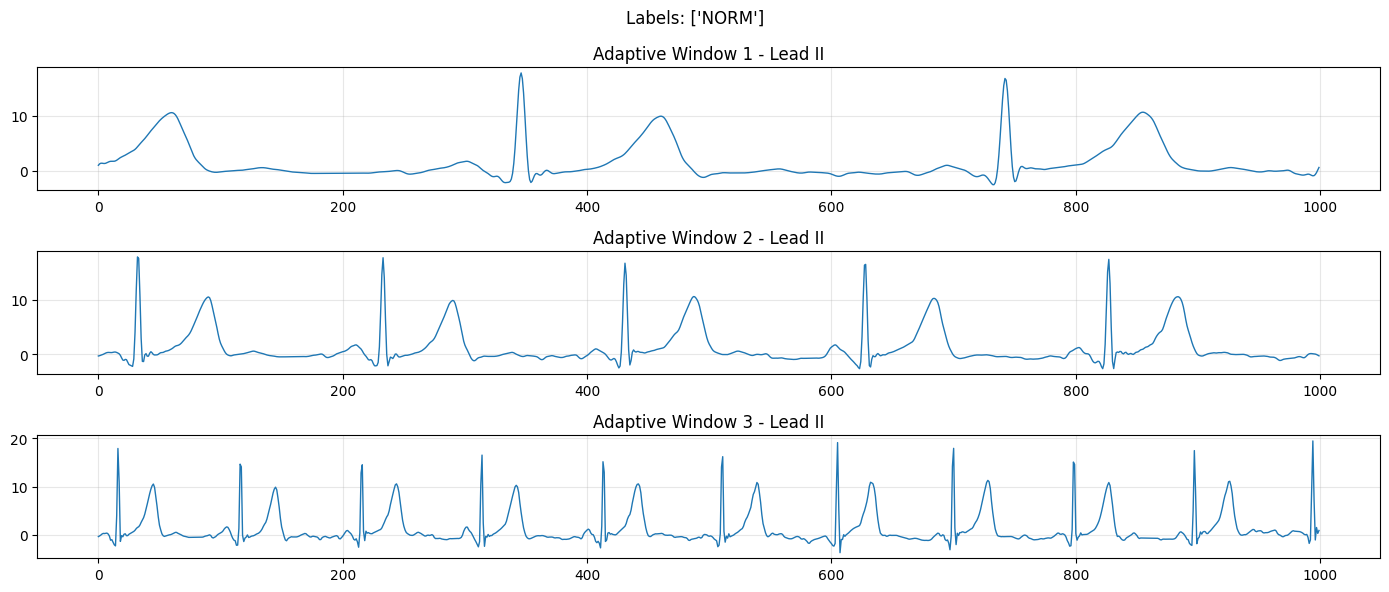

In [ ]:

def pad_or_crop(x: np.ndarray, target_len: int) -> np.ndarray:
    """
    Input:
      x shape = [time, leads]

    Output:
      x shape = [target_len, leads]
    """
    if x.shape[0] == target_len:
        return x

    if x.shape[0] > target_len:
        start = (x.shape[0] - target_len) // 2
        return x[start:start + target_len]

    pad = target_len - x.shape[0]
    left = pad // 2
    right = pad - left

    return np.pad(
        x,
        pad_width=((left, right), (0, 0)),
        mode="constant",
        constant_values=0
    )


def baseline_wander_removal(
    x: np.ndarray,
    fs: int,
    cutoff: float = 0.5,
    order: int = 3
) -> np.ndarray:
    """
    Removes low-frequency baseline drift.
    """
    nyquist = fs / 2.0
    normalized_cutoff = cutoff / nyquist

    b, a = sps.butter(
        N=order,
        Wn=normalized_cutoff,
        btype="highpass"
    )

    return sps.filtfilt(b, a, x, axis=0).astype(np.float32)


def notch_filter(
    x: np.ndarray,
    fs: int,
    freq: float = 50.0,
    quality: float = 30.0
) -> np.ndarray:
    """
    Removes power-line interference.

    For 100 Hz ECG, Nyquist is 50 Hz, so a 50 Hz notch is skipped.
    """
    nyquist = fs / 2.0

    if freq >= nyquist:
        return x.astype(np.float32)

    b, a = sps.iirnotch(
        w0=freq / nyquist,
        Q=quality
    )

    return sps.filtfilt(b, a, x, axis=0).astype(np.float32)


def wavelet_denoise_1d(
    signal_1d: np.ndarray,
    wavelet: str = "db4",
    level: int = 1
) -> np.ndarray:
    """
    Light wavelet denoising for one ECG lead.
    This is kept light for speed on Colab.
    """
    coeffs = pywt.wavedec(
        signal_1d,
        wavelet=wavelet,
        mode="symmetric",
        level=level
    )

    detail = coeffs[-1]

    if len(detail) == 0:
        return signal_1d

    sigma = np.median(np.abs(detail)) / 0.6745
    threshold = sigma * np.sqrt(2.0 * np.log(signal_1d.size))

    denoised_coeffs = [coeffs[0]]

    for c in coeffs[1:]:
        denoised_coeffs.append(
            pywt.threshold(c, threshold, mode="soft")
        )

    reconstructed = pywt.waverec(
        denoised_coeffs,
        wavelet=wavelet,
        mode="symmetric"
    )

    return reconstructed[:signal_1d.size]


def wavelet_denoise(x: np.ndarray) -> np.ndarray:
    """
    Applies wavelet denoising lead-by-lead.
    """
    out = np.zeros_like(x, dtype=np.float32)

    for lead_idx in range(x.shape[1]):
        out[:, lead_idx] = wavelet_denoise_1d(
            x[:, lead_idx]
        ).astype(np.float32)

    return out

def robust_normalize(
    x: np.ndarray,
    eps: float = 1e-6
) -> np.ndarray:
    """
    Per-lead median/MAD normalization.
    """
    median = np.median(x, axis=0, keepdims=True)
    mad = np.median(np.abs(x - median), axis=0, keepdims=True)

    x = (x - median) / (1.4826 * mad + eps)

    x = np.nan_to_num(
        x,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return x.astype(np.float32)

def preprocess_ecg(
    x: np.ndarray,
    fs: int
) -> np.ndarray:
    """
    Raw ECG
    -> baseline wander removal
    -> notch filtering
    -> wavelet denoising
    -> robust normalization
    """
    x = baseline_wander_removal(
        x=x,
        fs=fs,
        cutoff=0.5,
        order=3
    )

    x = notch_filter(
        x=x,
        fs=fs,
        freq=50.0,
        quality=30.0
    )

    x = wavelet_denoise(x)

    x = robust_normalize(x)

    return x.astype(np.float32)

class AdaptiveWindowGenerator:
    """
    Generates 3 windows around the highest-energy ECG region.

    For 100 Hz:
      2.5 sec -> 250 samples
      5.0 sec -> 500 samples
      10 sec  -> 1000 samples

    Then every window is resized to cfg.signal_len.
    """

    def __init__(
        self,
        fs: int,
        full_len: int,
        window_seconds: Sequence[float] = (2.5, 5.0, 10.0),
        train_jitter_seconds: float = 0.35
    ):
        self.fs = fs
        self.full_len = full_len

        self.window_lengths = [
            int(seconds * fs) for seconds in window_seconds
        ]

        self.train_jitter = int(train_jitter_seconds * fs)

    def __call__(
        self,
        x: np.ndarray,
        train: bool = False
    ) -> List[np.ndarray]:
        """
        Input:
          x shape = [time, leads]

        Output:
          list of 3 windows, each [full_len, leads]
        """
        energy = np.mean(np.abs(x), axis=1)

        kernel_size = min(51, len(energy))

        if kernel_size % 2 == 0:
            kernel_size -= 1

        if kernel_size >= 3:
            smooth_energy = sps.medfilt(
                energy,
                kernel_size=kernel_size
            )
        else:
            smooth_energy = energy

        center = int(np.argmax(smooth_energy))

        if train and self.train_jitter > 0:
            center += random.randint(
                -self.train_jitter,
                self.train_jitter
            )

        center = int(np.clip(center, 0, x.shape[0] - 1))

        windows = []

        for length in self.window_lengths:
            half = length // 2

            start = max(0, center - half)
            end = min(x.shape[0], start + length)
            start = max(0, end - length)

            crop = x[start:end]
            crop = pad_or_crop(crop, length)

            if length != self.full_len:
                crop = sps.resample(
                    crop,
                    self.full_len,
                    axis=0
                ).astype(np.float32)

            windows.append(crop.astype(np.float32))

        return windows


window_generator = AdaptiveWindowGenerator(
    fs=cfg.sampling_rate,
    full_len=cfg.signal_len
)

print("Adaptive window generator ready.")
print("Sampling rate:", cfg.sampling_rate)
print("Signal length:", cfg.signal_len)

class PTBXLDataset(Dataset):
    """
    Streams ECGs from WFDB records.

    Output:
      x shape = [3, 12, signal_len]
      y shape = [5]
    """

    def __init__(
        self,
        frame: pd.DataFrame,
        data_dir: str,
        sampling_rate: int,
        signal_len: int,
        train: bool = False,
        use_preprocessing: bool = True
    ):
        self.frame = frame.reset_index(drop=False)
        self.data_dir = Path(data_dir)
        self.sampling_rate = sampling_rate
        self.signal_len = signal_len
        self.train = train
        self.use_preprocessing = use_preprocessing

        self.filename_col = (
            "filename_hr" if sampling_rate == 500 else "filename_lr"
        )

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]

        record_path = self.data_dir / row[self.filename_col]

        x, _ = wfdb.rdsamp(str(record_path))

        x = x.astype(np.float32)

        x = pad_or_crop(
            x=x,
            target_len=self.signal_len
        )

        if self.use_preprocessing:
            x = preprocess_ecg(
                x=x,
                fs=self.sampling_rate
            )

        windows = window_generator(
            x=x,
            train=self.train
        )

        # [scales, time, leads]
        x = np.stack(windows, axis=0)

        # Conv1D format: [scales, leads, time]
        x = torch.tensor(x).permute(0, 2, 1).float()

        y = torch.tensor(row["labels"]).float()

        return x, y

train_dataset = PTBXLDataset(
    frame=train_df,
    data_dir=cfg.data_dir,
    sampling_rate=cfg.sampling_rate,
    signal_len=cfg.signal_len,
    train=True,
    use_preprocessing=True
)

val_dataset = PTBXLDataset(
    frame=val_df,
    data_dir=cfg.data_dir,
    sampling_rate=cfg.sampling_rate,
    signal_len=cfg.signal_len,
    train=False,
    use_preprocessing=True
)

test_dataset = PTBXLDataset(
    frame=test_df,
    data_dir=cfg.data_dir,
    sampling_rate=cfg.sampling_rate,
    signal_len=cfg.signal_len,
    train=False,
    use_preprocessing=True
)

print("Datasets created.")
print("Train:", len(train_dataset))
print("Val:  ", len(val_dataset))
print("Test: ", len(test_dataset))

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True if cfg.num_workers > 0 else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=False,
    persistent_workers=True if cfg.num_workers > 0 else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=False,
    persistent_workers=True if cfg.num_workers > 0 else False
)

print("DataLoaders ready.")

batch_x, batch_y = next(iter(train_loader))

print("\nBatch check:")
print("batch_x shape:", batch_x.shape)
print("batch_y shape:", batch_y.shape)

assert batch_x.shape[1] == 3
assert batch_x.shape[2] == cfg.num_leads
assert batch_x.shape[3] == cfg.signal_len
assert batch_y.shape[1] == cfg.num_classes

print("Batch shape check passed.")

def plot_one_ecg_batch_sample(batch_x, batch_y, class_names):
    """
    Plots Lead II from one sample and all 3 adaptive windows.
    """
    sample = batch_x[0].cpu().numpy()
    label = batch_y[0].cpu().numpy()

    label_names = [
        class_names[i]
        for i, value in enumerate(label)
        if value == 1
    ]

    plt.figure(figsize=(14, 6))

    for scale_idx in range(sample.shape[0]):
        lead_ii = sample[scale_idx, 1, :]

        plt.subplot(3, 1, scale_idx + 1)
        plt.plot(lead_ii, linewidth=1)
        plt.title(f"Adaptive Window {scale_idx + 1} - Lead II")
        plt.grid(alpha=0.3)

    plt.suptitle(f"Labels: {label_names}")
    plt.tight_layout()
    plt.show()


plot_one_ecg_batch_sample(
    batch_x=batch_x,
    batch_y=batch_y,
    class_names=cfg.classes
)



In [ ]:

def softplus_rho(rho: torch.Tensor) -> torch.Tensor:
    return torch.log1p(torch.exp(rho))


def gaussian_kl(
    mu: torch.Tensor,
    sigma: torch.Tensor,
    prior_sigma: float = 1.0
) -> torch.Tensor:
    """
    KL divergence:
      posterior N(mu, sigma^2)
      prior     N(0, prior_sigma^2)
    """
    prior_var = prior_sigma ** 2
    var = sigma ** 2

    kl = 0.5 * torch.sum(
        (var + mu ** 2) / prior_var
        - 1.0
        + math.log(prior_var)
        - torch.log(var + 1e-8)
    )

    return kl


def sum_kl(module: nn.Module) -> torch.Tensor:
    """
    Recursively collect KL from Bayesian child layers.
    """
    params = list(module.parameters(recurse=True))

    if len(params) == 0:
        return torch.tensor(0.0, device=device)

    kl = torch.tensor(0.0, device=params[0].device)

    for child in module.children():
        if hasattr(child, "kl_loss"):
            kl = kl + child.kl_loss()
        else:
            kl = kl + sum_kl(child)

    return kl


class BayesianModule(nn.Module):
    def kl_loss(self) -> torch.Tensor:
        kl = torch.tensor(0.0, device=next(self.parameters()).device)

        for child in self.children():
            if hasattr(child, "kl_loss"):
                kl = kl + child.kl_loss()
            else:
                kl = kl + sum_kl(child)

        return kl


class BayesianConv1d(nn.Module):
    """
    Bayesian 1D convolution with Gaussian posterior weights.
    """

    def __init__(
        self,
        in_ch: int,
        out_ch: int,
        kernel_size: int,
        stride: int = 1,
        padding: int = 0,
        groups: int = 1
    ):
        super().__init__()

        weight_shape = (
            out_ch,
            in_ch // groups,
            kernel_size
        )

        self.weight_mu = nn.Parameter(
            torch.empty(weight_shape).normal_(0.0, 0.05)
        )

        self.weight_rho = nn.Parameter(
            torch.empty(weight_shape).normal_(-5.0, 0.1)
        )

        self.bias_mu = nn.Parameter(
            torch.zeros(out_ch)
        )

        self.bias_rho = nn.Parameter(
            torch.empty(out_ch).normal_(-5.0, 0.1)
        )

        self.stride = stride
        self.padding = padding
        self.groups = groups

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        weight_sigma = softplus_rho(self.weight_rho)
        bias_sigma = softplus_rho(self.bias_rho)

        if self.training:
            weight = self.weight_mu + weight_sigma * torch.randn_like(weight_sigma)
            bias = self.bias_mu + bias_sigma * torch.randn_like(bias_sigma)
        else:
            weight = self.weight_mu
            bias = self.bias_mu

        return F.conv1d(
            x,
            weight,
            bias,
            stride=self.stride,
            padding=self.padding,
            groups=self.groups
        )

    def kl_loss(self) -> torch.Tensor:
        return (
            gaussian_kl(self.weight_mu, softplus_rho(self.weight_rho))
            + gaussian_kl(self.bias_mu, softplus_rho(self.bias_rho))
        )

class BayesianLinear(nn.Module):
    """
    Bayesian fully connected layer.
    """

    def __init__(
        self,
        in_features: int,
        out_features: int
    ):
        super().__init__()

        self.weight_mu = nn.Parameter(
            torch.empty(out_features, in_features).normal_(0.0, 0.05)
        )

        self.weight_rho = nn.Parameter(
            torch.empty(out_features, in_features).normal_(-5.0, 0.1)
        )

        self.bias_mu = nn.Parameter(
            torch.zeros(out_features)
        )

        self.bias_rho = nn.Parameter(
            torch.empty(out_features).normal_(-5.0, 0.1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        weight_sigma = softplus_rho(self.weight_rho)
        bias_sigma = softplus_rho(self.bias_rho)

        if self.training:
            weight = self.weight_mu + weight_sigma * torch.randn_like(weight_sigma)
            bias = self.bias_mu + bias_sigma * torch.randn_like(bias_sigma)
        else:
            weight = self.weight_mu
            bias = self.bias_mu

        return F.linear(x, weight, bias)

    def kl_loss(self) -> torch.Tensor:
        return (
            gaussian_kl(self.weight_mu, softplus_rho(self.weight_rho))
            + gaussian_kl(self.bias_mu, softplus_rho(self.bias_rho))
        )


class BayesianResidualBlock(BayesianModule):
    """
    Residual block using Bayesian convolutions.
    """

    def __init__(
        self,
        channels: int,
        kernel_size: int = 7,
        dropout: float = 0.15
    ):
        super().__init__()

        padding = kernel_size // 2

        self.conv1 = BayesianConv1d(
            in_ch=channels,
            out_ch=channels,
            kernel_size=kernel_size,
            padding=padding
        )

        self.bn1 = nn.BatchNorm1d(channels)

        self.conv2 = BayesianConv1d(
            in_ch=channels,
            out_ch=channels,
            kernel_size=kernel_size,
            padding=padding
        )

        self.bn2 = nn.BatchNorm1d(channels)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.gelu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = F.gelu(out)

        return out

class MultiScaleBayesianCNN(BayesianModule):
    """
    Extracts ECG morphology using multiple temporal kernel sizes.

    Input:
      [B, 12, signal_len]

    Output:
      [B, tokens, hidden]
    """

    def __init__(
        self,
        in_ch: int = 12,
        hidden: int = 128,
        dropout: float = 0.20
    ):
        super().__init__()

        # hidden=128, branch_ch=32, fused=128 after four branches
        kernels = (5, 9, 17, 31)
        branch_ch = hidden // len(kernels)

        self.branches = nn.ModuleList()

        for kernel_size in kernels:
            branch = nn.Sequential(
                BayesianConv1d(
                    in_ch=in_ch,
                    out_ch=branch_ch,
                    kernel_size=kernel_size,
                    stride=2,
                    padding=kernel_size // 2
                ),
                nn.BatchNorm1d(branch_ch),
                nn.GELU(),
                nn.Dropout(dropout),

                BayesianResidualBlock(
                    channels=branch_ch,
                    kernel_size=7,
                    dropout=dropout
                )
            )

            self.branches.append(branch)

        fused_channels = branch_ch * len(kernels)

        self.proj = nn.Sequential(
            nn.Conv1d(
                fused_channels,
                hidden,
                kernel_size=1
            ),
            nn.BatchNorm1d(hidden),
            nn.GELU()
        )

        self.res1 = BayesianResidualBlock(
            channels=hidden,
            kernel_size=9,
            dropout=dropout
        )

        self.res2 = BayesianResidualBlock(
            channels=hidden,
            kernel_size=9,
            dropout=dropout
        )

        # For 1000 samples:
        # stride 2 -> 500
        # pool 4  -> 125 tokens
        self.pool = nn.AvgPool1d(
            kernel_size=4,
            stride=4
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        branch_outputs = []

        for branch in self.branches:
            branch_outputs.append(branch(x))

        z = torch.cat(branch_outputs, dim=1)

        z = self.proj(z)
        z = self.res1(z)
        z = self.res2(z)
        z = self.pool(z)

        # [B, C, T] -> [B, T, C]
        z = z.transpose(1, 2)

        return z

class ResidualFusion(nn.Module):
    """
    Fuses the 3 adaptive windows/scales.

    Input:
      list of 3 tensors, each [B, tokens, hidden]

    Output:
      [B, tokens, hidden]
    """

    def __init__(
        self,
        hidden: int,
        n_scales: int = 3
    ):
        super().__init__()

        self.scale_weights = nn.Parameter(
            torch.zeros(n_scales)
        )

        self.gate = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.Sigmoid()
        )

        self.norm = nn.LayerNorm(hidden)

    def forward(
        self,
        scale_features: List[torch.Tensor]
    ) -> torch.Tensor:
        stacked = torch.stack(
            scale_features,
            dim=1
        )

        # [B, scales, tokens, hidden]
        weights = torch.softmax(
            self.scale_weights,
            dim=0
        ).view(1, -1, 1, 1)

        fused = (stacked * weights).sum(dim=1)

        gated = fused * self.gate(fused)

        return self.norm(fused + gated)

class FallbackMambaBlock(nn.Module):
    """
    Mamba-inspired state-space sequence block.

    Used when official mamba-ssm is unavailable.

    It performs:
      normalization
      gated projection
      depthwise temporal convolution
      selective state accumulation
      residual output

    This supports long-range ECG dependency modeling efficiently.
    """

    def __init__(
        self,
        d_model: int,
        dropout: float = 0.20
    ):
        super().__init__()

        self.norm = nn.LayerNorm(d_model)

        self.in_proj = nn.Linear(
            d_model,
            d_model * 2
        )

        self.depthwise = nn.Conv1d(
            d_model,
            d_model,
            kernel_size=5,
            padding=4,
            groups=d_model
        )

        self.param_proj = nn.Linear(
            d_model,
            d_model * 2
        )

        self.out_proj = nn.Linear(
            d_model,
            d_model
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x

        x = self.norm(x)

        u, gate = self.in_proj(x).chunk(
            2,
            dim=-1
        )

        # Local temporal mixing
        u = self.depthwise(
            u.transpose(1, 2)
        )

        u = u[:, :, :x.size(1)]
        u = u.transpose(1, 2)

        u = F.silu(u)

        delta, state_input = self.param_proj(u).chunk(
            2,
            dim=-1
        )

        delta = torch.sigmoid(delta)

        # Selective state accumulation over time
        state = torch.cumsum(
            delta * torch.tanh(state_input),
            dim=1
        )

        y = state * torch.sigmoid(gate)

        y = self.out_proj(y)
        y = self.dropout(y)

        return residual + y


class MambaEncoder(nn.Module):
    """
    Uses official Mamba if installed.
    Otherwise uses Mamba-inspired fallback block.
    """

    def __init__(
        self,
        hidden: int,
        layers: int,
        dropout: float
    ):
        super().__init__()

        self.use_official_mamba = OfficialMamba is not None

        self.blocks = nn.ModuleList()

        for _ in range(layers):
            if self.use_official_mamba:
                block = OfficialMamba(
                    d_model=hidden,
                    d_state=16,
                    d_conv=4,
                    expand=2
                )
            else:
                block = FallbackMambaBlock(
                    d_model=hidden,
                    dropout=dropout
                )

            self.blocks.append(block)

        self.norm = nn.LayerNorm(hidden)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for block in self.blocks:
            if self.use_official_mamba:
                x = x + block(x)
            else:
                x = block(x)

        x = self.norm(x)

        return x

class AttentionFusion(nn.Module):
    """
    Uses a CLS token and self-attention to create final ECG embedding.
    """

    def __init__(
        self,
        hidden: int,
        heads: int = 4,
        dropout: float = 0.20
    ):
        super().__init__()

        self.cls = nn.Parameter(
            torch.zeros(1, 1, hidden)
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=hidden,
            num_heads=heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(hidden)
        self.norm2 = nn.LayerNorm(hidden)

        self.ffn = nn.Sequential(
            nn.Linear(hidden, hidden * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * 4, hidden),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)

        cls = self.cls.expand(
            batch_size,
            -1,
            -1
        )

        z = torch.cat(
            [cls, x],
            dim=1
        )

        attn_out, _ = self.attn(
            z,
            z,
            z,
            need_weights=False
        )

        z = self.norm1(z + attn_out)

        ffn_out = self.ffn(z)

        z = self.norm2(z + ffn_out)

        return z[:, 0]


class BayesianECGMamba(BayesianModule):
    """
    Final architecture:

    ECG windows
    -> Bayesian Multi-scale CNN
    -> Residual scale fusion
    -> Mamba / Mamba-inspired encoder
    -> Attention fusion
    -> Bayesian classifier
    """

    def __init__(self, cfg: CFG):
        super().__init__()

        self.n_scales = 3

        self.cnn = MultiScaleBayesianCNN(
            in_ch=cfg.num_leads,
            hidden=cfg.hidden_dim,
            dropout=cfg.dropout
        )

        self.fusion = ResidualFusion(
            hidden=cfg.hidden_dim,
            n_scales=self.n_scales
        )

        self.mamba = MambaEncoder(
            hidden=cfg.hidden_dim,
            layers=cfg.mamba_layers,
            dropout=cfg.dropout
        )

        self.attn = AttentionFusion(
            hidden=cfg.hidden_dim,
            heads=4,
            dropout=cfg.dropout
        )

        self.head = nn.Sequential(
            nn.LayerNorm(cfg.hidden_dim),
            nn.Dropout(cfg.dropout),

            BayesianLinear(
                in_features=cfg.hidden_dim,
                out_features=cfg.hidden_dim // 2
            ),

            nn.GELU(),
            nn.Dropout(cfg.dropout),

            BayesianLinear(
                in_features=cfg.hidden_dim // 2,
                out_features=cfg.num_classes
            )
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input:
          [B, 3, 12, signal_len]

        Output:
          [B, 5]
        """
        scale_features = []

        for scale_idx in range(x.size(1)):
            one_scale = x[:, scale_idx]

            features = self.cnn(one_scale)

            scale_features.append(features)

        fused = self.fusion(scale_features)

        encoded = self.mamba(fused)

        pooled = self.attn(encoded)

        logits = self.head(pooled)

        return logits


model = BayesianECGMamba(cfg).to(device)

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("Model created.")
print(f"Total parameters: {total_params / 1e6:.2f}M")
print(f"Trainable parameters: {trainable_params / 1e6:.2f}M")

if OfficialMamba is not None:
    print("Encoder type: Official Mamba from mamba-ssm")
else:
    print("Encoder type: Mamba-inspired state-space fallback")

model.eval()

with torch.no_grad():
    sample_x, sample_y = next(iter(train_loader))

    sample_x = sample_x.to(device)
    sample_y = sample_y.to(device)

    sample_logits = model(sample_x)

print("\nForward-pass check:")
print("Input shape: ", sample_x.shape)
print("Target shape:", sample_y.shape)
print("Logit shape: ", sample_logits.shape)

assert sample_logits.shape[0] == sample_x.shape[0]
assert sample_logits.shape[1] == cfg.num_classes

print("Forward pass successful.")

Model created.
Total parameters: 1.85M
Trainable parameters: 1.85M
Encoder type: Mamba-inspired state-space fallback

Forward-pass check:
Input shape:  torch.Size([32, 3, 12, 1000])
Target shape: torch.Size([32, 5])
Logit shape:  torch.Size([32, 5])
Forward pass successful.


Checkpoint directory: /content/drive/MyDrive/ptbxl_bayesian_mamba_checkpoints

========== Epoch 1/30 ==========


/tmp/ipykernel_814/1886458546.py:246: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


Epoch 1:   0%|          | 0/533 [00:00<?, ?it/s]

/tmp/ipykernel_814/1886458546.py:184: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Predict:   0%|          | 0/68 [00:00<?, ?it/s]

...

Epoch 30:   0%|          | 0/533 [00:00<?, ?it/s]

/tmp/ipykernel_814/1886458546.py:184: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Predict:   0%|          | 0/68 [00:00<?, ?it/s]

Train loss: 0.3860
Train BCE:  0.3842
Train KL:   179.4328
Val AUROC: 0.8998
Val AUPRC: 0.7523
Val Label Accuracy: 0.8541
Val Exact Match: 0.5270
Val Macro F1: 0.6987
LR: 0.00000000

Training complete.
Best epoch: 17
Best validation AUROC: 0.9073
Best checkpoint: /content/drive/MyDrive/ptbxl_bayesian_mamba_checkpoints/best_model.pt
Last checkpoint: /content/drive/MyDrive/ptbxl_bayesian_mamba_checkpoints/last_model.pt
History CSV: /content/drive/MyDrive/ptbxl_bayesian_mamba_checkpoints/training_history.csv


,epoch,lr,train_loss,train_bce,train_kl,val_macro_auc,val_macro_auprc,val_label_accuracy,val_exact_match,val_macro_precision,val_macro_recall,val_macro_f1,val_micro_precision,val_micro_recall,val_micro_f1
25,26,8.645454e-06,0.397364,0.395570,179.432483,0.899232,0.751260,0.853495,0.533085,0.659807,0.746610,0.693771,0.689451,0.792893,0.737563
26,27,4.894348e-06,0.391865,0.390071,179.432615,0.899144,0.752108,0.851911,0.522833,0.652969,0.754300,0.693456,0.684438,0.797200,0.736528
27,28,2.185240e-06,0.389267,0.387473,179.432714,0.900394,0.753882,0.853029,0.527959,0.653506,0.760359,0.697357,0.685145,0.802943,0.739382
28,29,5.478105e-07,0.387033,0.385239,179.432766,0.898329,0.750045,0.852004,0.526561,0.655322,0.746218,0.691274,0.686372,0.791816,0.735333
29,30,0.000000e+00,0.385960,0.384166,179.432785,0.899845,0.752325,0.854147,0.527027,0.656132,0.758986,0.698660,0.688020,0.801866,0.740593


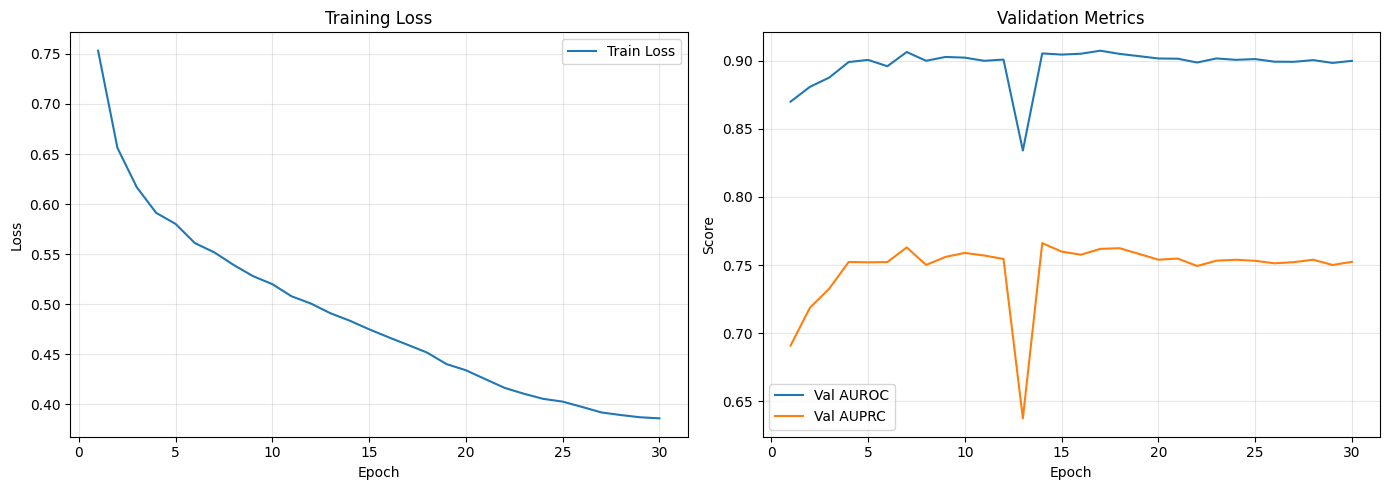


Part 5 complete.


In [ ]:

def batch_to_device(batch):
    x, y = batch

    x = x.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)

    return x, y

def compute_metrics(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5
):
    """
    Multilabel classification metrics.
    """
    y_pred = (y_prob >= threshold).astype(np.float32)

    metrics = {}

    try:
        metrics["macro_auc"] = roc_auc_score(
            y_true,
            y_prob,
            average="macro"
        )
    except ValueError:
        metrics["macro_auc"] = float("nan")

    try:
        metrics["macro_auprc"] = average_precision_score(
            y_true,
            y_prob,
            average="macro"
        )
    except ValueError:
        metrics["macro_auprc"] = float("nan")

    metrics["label_accuracy"] = float(
        (y_pred == y_true).mean()
    )

    metrics["exact_match"] = float(
        (y_pred == y_true).all(axis=1).mean()
    )

    metrics["macro_precision"] = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    metrics["macro_recall"] = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    metrics["macro_f1"] = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    metrics["micro_precision"] = precision_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    )

    metrics["micro_recall"] = recall_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    )

    metrics["micro_f1"] = f1_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    )

    return metrics
@torch.no_grad()
def predict_deterministic(
    model: nn.Module,
    loader: DataLoader
):
    """
    Validation/test prediction without MC sampling.

    Bayesian layers use posterior mean weights in eval mode.
    """
    model.eval()

    all_targets = []
    all_probs = []

    for batch in tqdm(loader, desc="Predict", leave=False):
        x, y = batch_to_device(batch)

        logits = model(x)
        probs = torch.sigmoid(logits)

        all_targets.append(y.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    y_true = np.vstack(all_targets)
    y_prob = np.vstack(all_probs)

    return y_true, y_prob


@torch.no_grad()
def evaluate_deterministic(
    model: nn.Module,
    loader: DataLoader
):
    y_true, y_prob = predict_deterministic(
        model=model,
        loader=loader
    )

    return compute_metrics(
        y_true=y_true,
        y_prob=y_prob,
        threshold=0.5
    )

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scaler,
    epoch: int
):
    model.train()

    total_loss = 0.0
    total_bce = 0.0
    total_kl = 0.0

    bce_loss_fn = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    pbar = tqdm(
        loader,
        desc=f"Epoch {epoch}",
        leave=False
    )

    for step, batch in enumerate(pbar):
        x, y = batch_to_device(batch)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)

            bce_loss = bce_loss_fn(
                logits,
                y
            )

            kl_loss = model.kl_loss()

            # Normalize KL by dataset size
            kl_loss = kl_loss / max(1, len(loader.dataset))

            loss = bce_loss + cfg.kl_weight * kl_loss

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item())
        total_bce += float(bce_loss.item())
        total_kl += float(kl_loss.item())

        n = step + 1

        pbar.set_postfix(
            loss=f"{total_loss / n:.4f}",
            bce=f"{total_bce / n:.4f}",
            kl=f"{total_kl / n:.2f}"
        )

    n_batches = max(1, len(loader))

    return {
        "train_loss": total_loss / n_batches,
        "train_bce": total_bce / n_batches,
        "train_kl": total_kl / n_batches
    }

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cfg.epochs
)

scaler = torch.cuda.amp.GradScaler(
    enabled=(device.type == "cuda")
)


checkpoint_dir = Path("/content/drive/MyDrive/ptbxl_bayesian_mamba_checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

best_checkpoint_path = checkpoint_dir / "best_model.pt"
last_checkpoint_path = checkpoint_dir / "last_model.pt"
history_csv_path = checkpoint_dir / "training_history.csv"

print("Checkpoint directory:", checkpoint_dir)

history = []

best_auc = -1.0
best_epoch = -1

for epoch in range(1, cfg.epochs + 1):
    print(f"\n========== Epoch {epoch}/{cfg.epochs} ==========")

    train_stats = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        scaler=scaler,
        epoch=epoch
    )

    val_metrics = evaluate_deterministic(
        model=model,
        loader=val_loader
    )

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_row = {
        "epoch": epoch,
        "lr": current_lr,
        **train_stats,
        **{f"val_{k}": v for k, v in val_metrics.items()}
    }

    history.append(epoch_row)

    print("Train loss:", f"{train_stats['train_loss']:.4f}")
    print("Train BCE: ", f"{train_stats['train_bce']:.4f}")
    print("Train KL:  ", f"{train_stats['train_kl']:.4f}")

    print("Val AUROC:", f"{val_metrics['macro_auc']:.4f}")
    print("Val AUPRC:", f"{val_metrics['macro_auprc']:.4f}")
    print("Val Label Accuracy:", f"{val_metrics['label_accuracy']:.4f}")
    print("Val Exact Match:", f"{val_metrics['exact_match']:.4f}")
    print("Val Macro F1:", f"{val_metrics['macro_f1']:.4f}")
    print("LR:", f"{current_lr:.8f}")

    # Save last checkpoint
    torch.save(
        {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "cfg": cfg.__dict__,
            "classes": cfg.classes,
            "history": history,
            "best_auc": best_auc,
            "best_epoch": best_epoch,
            "encoder_type": "official_mamba" if OfficialMamba is not None else "mamba_inspired"
        },
        last_checkpoint_path
    )

    # Save training history every epoch
    pd.DataFrame(history).to_csv(
        history_csv_path,
        index=False
    )

    val_auc = val_metrics["macro_auc"]

    if not math.isnan(val_auc) and val_auc > best_auc:
        best_auc = val_auc
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "cfg": cfg.__dict__,
                "classes": cfg.classes,
                "history": history,
                "best_auc": best_auc,
                "best_epoch": best_epoch,
                "encoder_type": "official_mamba" if OfficialMamba is not None else "mamba_inspired"
            },
            best_checkpoint_path
        )

        print("Saved new best checkpoint.")
        print("Best epoch:", best_epoch)
        print("Best validation AUROC:", f"{best_auc:.4f}")



history_df = pd.DataFrame(history)
history_df.to_csv(history_csv_path, index=False)

print("\nTraining complete.")
print("Best epoch:", best_epoch)
print("Best validation AUROC:", f"{best_auc:.4f}")
print("Best checkpoint:", best_checkpoint_path)
print("Last checkpoint:", last_checkpoint_path)
print("History CSV:", history_csv_path)

display(history_df.tail())


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["epoch"], history_df["val_macro_auc"], label="Val AUROC")
plt.plot(history_df["epoch"], history_df["val_macro_auprc"], label="Val AUPRC")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:

@torch.no_grad()
def predict(model, loader):

    model.eval()

    y_true = []
    y_prob = []

    for x, y in tqdm(loader):

        x = x.to(device)

        logits = model(x)

        probs = torch.sigmoid(logits)

        y_true.append(y.numpy())
        y_prob.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)

    return y_true, y_prob


y_true, y_prob = predict(model, test_loader)

metrics = compute_metrics(y_true, y_prob)

print("\nTest Metrics\n")

for k, v in metrics.items():
    print(f"{k:25s}: {v:.4f}")

  0%|          | 0/68 [00:00<?, ?it/s]


Test Metrics

macro_auc                : 0.8947
macro_auprc              : 0.7559
label_accuracy           : 0.8536
exact_match              : 0.5385
macro_precision          : 0.6571
macro_recall             : 0.7607
macro_f1                 : 0.6979
micro_precision          : 0.6867
micro_recall             : 0.7984
micro_f1                 : 0.7383


In [ ]:

print("\nClassification Report")

y_pred = (y_prob >= 0.5).astype(int)

for i, cls in enumerate(cfg.classes):

    print("\n")
    print("="*50)
    print(cls)
    print("="*50)

    print(classification_report(
        y_true[:, i],
        y_pred[:, i],
        digits=4
    ))


Classification Report


NORM
              precision    recall  f1-score   support

         0.0     0.9308    0.7883    0.8536      1195
         1.0     0.7792    0.9273    0.8468       963

    accuracy                         0.8503      2158
   macro avg     0.8550    0.8578    0.8502      2158
weighted avg     0.8632    0.8503    0.8506      2158



MI
              precision    recall  f1-score   support

         0.0     0.8848    0.9359    0.9096      1608
         1.0     0.7746    0.6436    0.7031       550

    accuracy                         0.8614      2158
   macro avg     0.8297    0.7898    0.8064      2158
weighted avg     0.8567    0.8614    0.8570      2158



STTC
              precision    recall  f1-score   support

         0.0     0.9466    0.8668    0.9050      1637
         1.0     0.6692    0.8464    0.7475       521

    accuracy                         0.8619      2158
   macro avg     0.8079    0.8566    0.8262      2158
weighted avg     0.8797    0.861

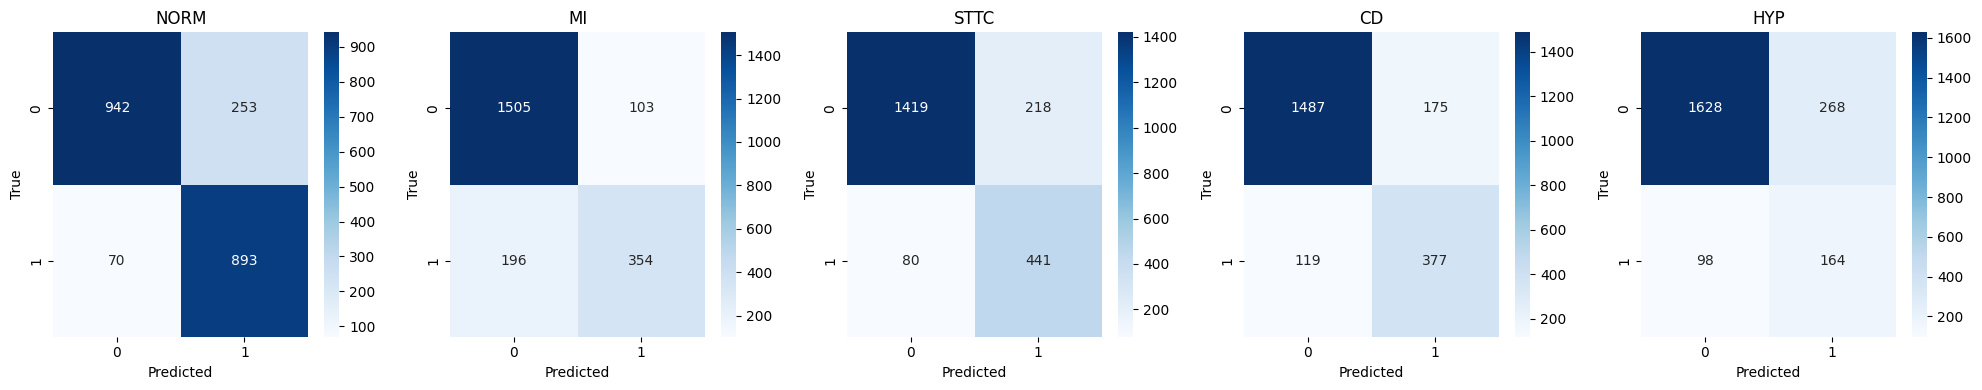

In [ ]:

cms = multilabel_confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, len(cfg.classes),
                         figsize=(20,4))

for i, cm in enumerate(cms):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i]
    )

    axes[i].set_title(cfg.classes[i])
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

plt.tight_layout()
plt.show()

In [ ]:

@torch.no_grad()
def mc_predict(model, x, mc_samples=10):

    model.train()

    probs = []

    for _ in range(mc_samples):

        logits = model(x)

        probs.append(
            torch.sigmoid(logits).cpu().numpy()
        )

    probs = np.stack(probs)

    mean_prob = probs.mean(axis=0)
    std_prob = probs.std(axis=0)

    confidence = 1.0 - std_prob

    return mean_prob, std_prob, confidence

In [ ]:

all_probs = []
all_conf = []

for x, _ in tqdm(test_loader):

    x = x.to(device)

    mean_prob, std_prob, confidence = mc_predict(
        model,
        x,
        cfg.mc_samples
    )

    all_probs.append(mean_prob)
    all_conf.append(confidence)

all_probs = np.concatenate(all_probs)
all_conf = np.concatenate(all_conf)

print("\nAverage Bayesian Confidence")

for i, cls in enumerate(cfg.classes):

    print(
        f"{cls:8s}: {100*all_conf[:,i].mean():.2f}%"
    )

  0%|          | 0/68 [00:00<?, ?it/s]


Average Bayesian Confidence
NORM    : 95.16%
MI      : 94.08%
STTC    : 95.07%
CD      : 94.10%
HYP     : 93.82%


In [ ]:


idx = np.random.randint(len(test_dataset))

x, y = test_dataset[idx]

x = x.unsqueeze(0).to(device)

mean_prob, std_prob, confidence = mc_predict(
    model,
    x,
    cfg.mc_samples
)

mean_prob = mean_prob[0]
confidence = confidence[0]

best = np.argmax(mean_prob)

print("="*60)
print("Bayesian ECG Prediction")
print("="*60)

print(f"\nPredicted Class : {cfg.classes[best]}")
print(f"Probability     : {100*mean_prob[best]:.2f}%")
print(f"Confidence      : {100*confidence[best]:.2f}%")

print("\nPer-class Results\n")

for i, cls in enumerate(cfg.classes):

    print(
        f"{cls:8s}"
        f" Probability = {100*mean_prob[i]:6.2f}%"
        f"   Confidence = {100*confidence[i]:6.2f}%"
    )

print("\nGround Truth")

truth = [
    cfg.classes[i]
    for i,v in enumerate(y.numpy())
    if v==1
]

print(truth)

Bayesian ECG Prediction

Predicted Class : CD
Probability     : 86.44%
Confidence      : 91.14%

Per-class Results

NORM     Probability =   9.26%   Confidence =  92.19%
MI       Probability =  82.58%   Confidence =  90.22%
STTC     Probability =  27.50%   Confidence =  88.10%
CD       Probability =  86.44%   Confidence =  91.14%
HYP      Probability =  23.18%   Confidence =  89.79%

Ground Truth
['MI', 'CD', 'HYP']


In [ ]:


diagnosis = cfg.classes[np.argmax(mean_prob)]

mapping = {
    "NORM":"Normal ECG",
    "MI":"Myocardial Infarction",
    "STTC":"ST-T Change",
    "CD":"Conduction Disturbance",
    "HYP":"Hypertrophy"
}

print("\n")
print("="*55)
print("FINAL ECG REPORT")
print("="*55)

print(
    f"Diagnosis  : {mapping[diagnosis]}"
)

print(
    f"Probability: {100*np.max(mean_prob):.2f}%"
)

print(
    f"Confidence : {100*np.max(confidence):.2f}%"
)

print("="*55)



FINAL ECG REPORT
Diagnosis  : Conduction Disturbance
Probability: 86.44%
Confidence : 92.19%


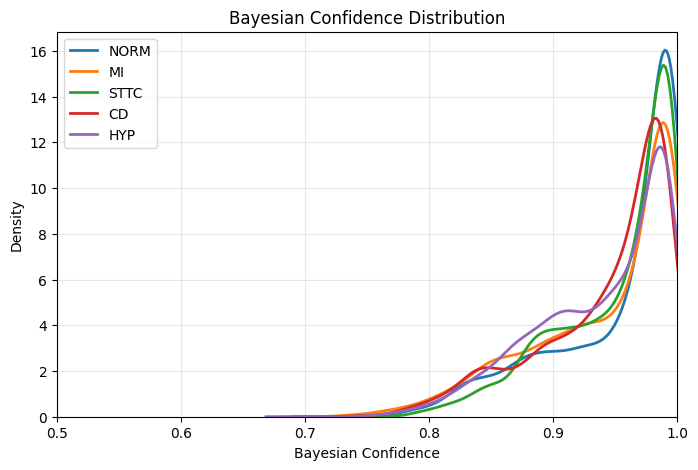

In [ ]:

plt.figure(figsize=(8,5))

for i, cls in enumerate(cfg.classes):

    sns.kdeplot(
        all_conf[:, i],
        label=cls,
        linewidth=2
    )

plt.xlim(0.5,1.0)
plt.xlabel("Bayesian Confidence")
plt.ylabel("Density")
plt.title("Bayesian Confidence Distribution")
plt.grid(alpha=.3)
plt.legend()
plt.show()

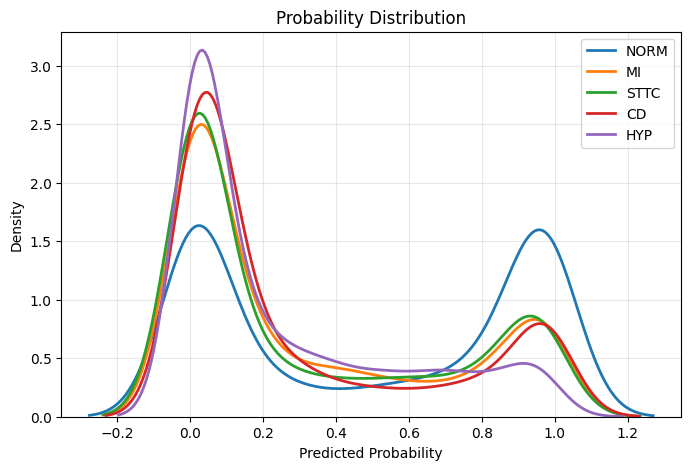

In [ ]:


plt.figure(figsize=(8,5))

for i, cls in enumerate(cfg.classes):

    sns.kdeplot(
        all_probs[:,i],
        label=cls,
        linewidth=2
    )

plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.title("Probability Distribution")
plt.grid(alpha=.3)
plt.legend()
plt.show()